In [1]:
import joblib
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
import xgboost
print(xgboost.__version__)

3.3.0


In [17]:
import hashlib

with open("../models/dispatch_time_model (1).pkl", "rb") as f:
    print(hashlib.md5(f.read()).hexdigest())

39928bbc74c082acecd1f93dfee18ba1


In [3]:
import xgboost
print(xgboost.__version__)
print(xgboost.build_info())

3.3.0
{'BUILTIN_PREFETCH_PRESENT': False, 'CUDA_VERSION': [12, 9], 'DEBUG': False, 'MM_PREFETCH_PRESENT': True, 'THRUST_VERSION': [2, 8, 2], 'USE_CUDA': True, 'USE_DLOPEN_NCCL': False, 'USE_FEDERATED': False, 'USE_NCCL': False, 'USE_NVCOMP': False, 'USE_OPENMP': True, 'USE_RMM': False, 'libxgboost': 'c:\\Users\\Nidhi\\OneDrive\\Documents\\AI-Emergency-Ambulance\\.venv312\\Lib\\site-packages\\xgboost\\lib\\xgboost.dll'}


In [4]:
from xgboost import XGBRegressor

model = XGBRegressor()
model.load_model("../models/dispatch_time_model.json")

print("JSON Loaded Successfully")

JSON Loaded Successfully


In [5]:
from xgboost import XGBRegressor, XGBClassifier

dispatch_model = XGBRegressor()
dispatch_model.load_model("../models/dispatch_time_model.json")

eta_model = XGBRegressor()
eta_model.load_model("../models/ETA_Prediction_Model.json")

delay_model = XGBClassifier()
delay_model.load_model("../models/delay_classifier.json")

In [6]:
files = [
    "../models/incident_response_model.pkl",
    "../models/demand_forecast_model.pkl"
]

for f in files:
    try:
        joblib.load(f)
        print(f"✅ {f}")
    except Exception as e:
        print(f"❌ {f}")
        print(e)

✅ ../models/incident_response_model.pkl
✅ ../models/demand_forecast_model.pkl


In [7]:
import os

files = [
    "../models/dispatch_time_model (1).pkl",
    "../models/ETA_Prediction_Model.pkl",
    "../models/delay_classifier.pkl"
]

for f in files:
    print(f, os.path.getsize(f), "bytes")

../models/dispatch_time_model (1).pkl 8016501 bytes
../models/ETA_Prediction_Model.pkl 4594419 bytes
../models/delay_classifier.pkl 3950690 bytes


In [8]:
response_model = joblib.load("../models/incident_response_model.pkl")

dispatch_model = XGBRegressor()
dispatch_model.load_model("../models/dispatch_time_model.json")

eta_model = XGBRegressor()
eta_model.load_model("../models/ETA_Prediction_Model.json")

delay_model = XGBClassifier()
delay_model.load_model("../models/delay_classifier.json")

demand_model = joblib.load("../models/demand_forecast_model.pkl")

In [9]:
import os
import joblib

os.makedirs("artifacts", exist_ok=True)

joblib.dump(response_model, "artifacts/response_model.pkl")
joblib.dump(dispatch_model, "artifacts/dispatch_model.pkl")
joblib.dump(eta_model, "artifacts/eta_model.pkl")
joblib.dump(delay_model, "artifacts/delay_model.pkl")
joblib.dump(demand_model, "artifacts/demand_model.pkl")

print("✅ All models saved successfully!")

✅ All models saved successfully!


In [28]:
X_response_test = pd.read_csv("../test_data/X_response_test.csv")
y_response_test = pd.read_csv("../test_data/y_response_test.csv")

X_dispatch_test = pd.read_csv("../test_data/X_dispatch_test.csv")
y_dispatch_test = pd.read_csv("../test_data/y_dispatch_test.csv")

X_eta_test = pd.read_csv("../test_data/X_eta_test.csv")
y_eta_test = pd.read_csv("../test_data/y_eta_test.csv")

X_delay_test = pd.read_csv("../test_data/X_delay_test.csv")
y_delay_test = pd.read_csv("../test_data/y_delay_test.csv")

X_demand_test = pd.read_csv("../test_data/X_demand_test.csv")
y_demand_test = pd.read_csv("../test_data/y_demand_test.csv")

In [29]:
pred = response_model.predict(X_response_test)

response_mae = mean_absolute_error(y_response_test, pred)

response_rmse = np.sqrt(mean_squared_error(y_response_test, pred))

response_r2 = r2_score(y_response_test, pred)

In [30]:
pred = dispatch_model.predict(X_dispatch_test)

dispatch_mae = mean_absolute_error(y_dispatch_test, pred)

dispatch_rmse = np.sqrt(mean_squared_error(y_dispatch_test, pred))

dispatch_r2 = r2_score(y_dispatch_test, pred)

In [31]:
pred = eta_model.predict(X_eta_test)

eta_mae = mean_absolute_error(y_eta_test, pred)

eta_rmse = np.sqrt(mean_squared_error(y_eta_test, pred))

eta_r2 = r2_score(y_eta_test, pred)

In [32]:
pred = delay_model.predict(X_delay_test)

delay_accuracy = accuracy_score(y_delay_test, pred)

delay_precision = precision_score(y_delay_test, pred)

delay_recall = recall_score(y_delay_test, pred)

delay_f1 = f1_score(y_delay_test, pred)

In [33]:
pred = demand_model.predict(X_demand_test)

demand_mae = mean_absolute_error(y_demand_test, pred)

demand_rmse = np.sqrt(mean_squared_error(y_demand_test, pred))

demand_r2 = r2_score(y_demand_test, pred)

In [34]:
results = pd.DataFrame({

    "Model":[
        "Incident Response",
        "Dispatch Time",
        "ETA Prediction",
        "Delay Classification",
        "Demand Forecasting"
    ],

    "MAE":[
        response_mae,
        dispatch_mae,
        eta_mae,
        None,
        demand_mae
    ],

    "RMSE":[
        response_rmse,
        dispatch_rmse,
        eta_rmse,
        None,
        demand_rmse
    ],

    "R2":[
        response_r2,
        dispatch_r2,
        eta_r2,
        None,
        demand_r2
    ],

    "Accuracy":[
        None,
        None,
        None,
        delay_accuracy,
        None
    ],

    "Precision":[
        None,
        None,
        None,
        delay_precision,
        None
    ],

    "Recall":[
        None,
        None,
        None,
        delay_recall,
        None
    ],

    "F1 Score":[
        None,
        None,
        None,
        delay_f1,
        None
    ]

})

results

,Model,MAE,RMSE,R2,Accuracy,Precision,Recall,F1 Score
0,Incident Response,307.195549,642.109073,0.648412,NaN,NaN,NaN,NaN
1,Dispatch Time,108.120209,473.528543,0.674482,NaN,NaN,NaN,NaN
2,ETA Prediction,40.124260,313.557648,0.927650,NaN,NaN,NaN,NaN
3,Delay Classification,NaN,NaN,NaN,0.726019,0.792296,0.763066,0.777407
4,Demand Forecasting,13.731746,17.805371,0.896164,NaN,NaN,NaN,NaN


In [35]:
results.to_csv("model_comparison.csv", index=False)

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

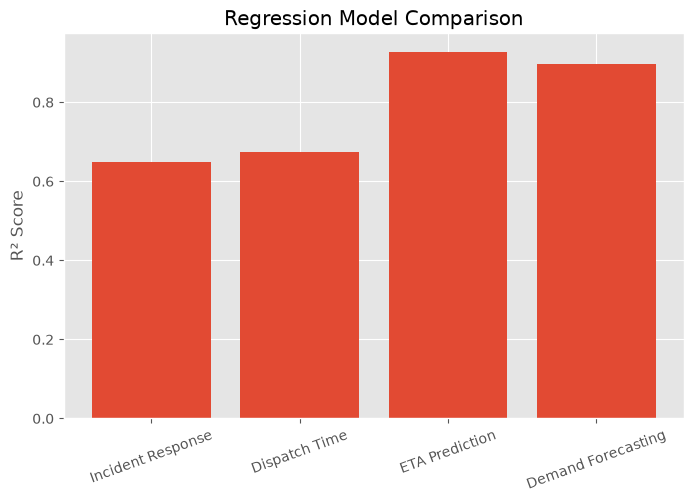

In [37]:
reg = results.dropna(subset=["R2"])

plt.figure(figsize=(8,5))
plt.bar(reg["Model"], reg["R2"])
plt.xticks(rotation=20)
plt.ylabel("R² Score")
plt.title("Regression Model Comparison")
plt.show()

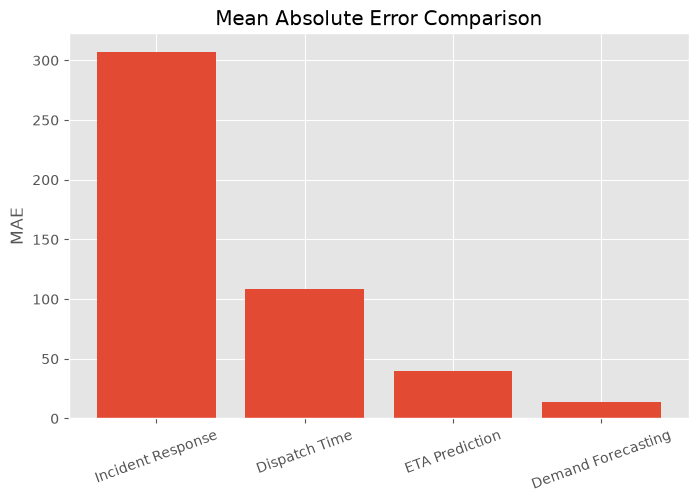

In [38]:
reg = results.dropna(subset=["MAE"])

plt.figure(figsize=(8,5))

plt.bar(reg["Model"], reg["MAE"])

plt.xticks(rotation=20)

plt.ylabel("MAE")

plt.title("Mean Absolute Error Comparison")

plt.show()

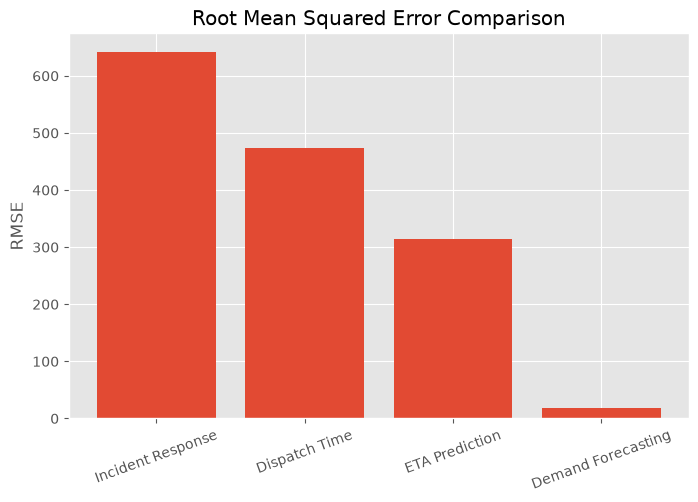

In [39]:
reg = results.dropna(subset=["RMSE"])

plt.figure(figsize=(8,5))

plt.bar(reg["Model"], reg["RMSE"])

plt.xticks(rotation=20)

plt.ylabel("RMSE")

plt.title("Root Mean Squared Error Comparison")

plt.show()

In [40]:
delay = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Score":[
        0.726019,
        0.792296,
        0.763066,
        0.777407
    ]

})

delay

,Metric,Score
0,Accuracy,0.726019
1,Precision,0.792296
2,Recall,0.763066
3,F1 Score,0.777407


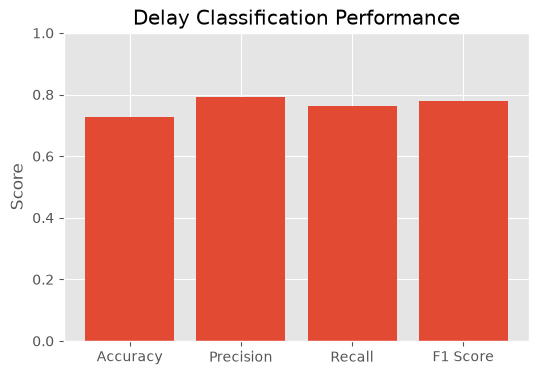

In [41]:
plt.figure(figsize=(6,4))

plt.bar(delay["Metric"], delay["Score"])

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Delay Classification Performance")

plt.show()

In [42]:
best_regression = results.loc[results["R2"].idxmax()]

print(best_regression)

Model        ETA Prediction
MAE                40.12426
RMSE             313.557648
R2                  0.92765
Accuracy                NaN
Precision               NaN
Recall                  NaN
F1 Score                NaN
Name: 2, dtype: object


In [43]:
print("""
PROJECT SUMMARY

• Total Models Developed : 5

• Best Regression Model :
  ETA Prediction
  R² = 0.9277

• Best Forecasting Model :
  Demand Forecasting
  R² = 0.8962

• Best Classification Model :
  Delay Classification
  Accuracy = 72.60%
  F1 Score = 77.74%

Overall, the proposed AI Ambulance Intelligence System demonstrates strong predictive performance across response time estimation, dispatch prediction, ETA prediction, delay detection, and ambulance demand forecasting.
""")


PROJECT SUMMARY

• Total Models Developed : 5

• Best Regression Model :
  ETA Prediction
  R² = 0.9277

• Best Forecasting Model :
  Demand Forecasting
  R² = 0.8962

• Best Classification Model :
  Delay Classification
  Accuracy = 72.60%
  F1 Score = 77.74%

Overall, the proposed AI Ambulance Intelligence System demonstrates strong predictive performance across response time estimation, dispatch prediction, ETA prediction, delay detection, and ambulance demand forecasting.



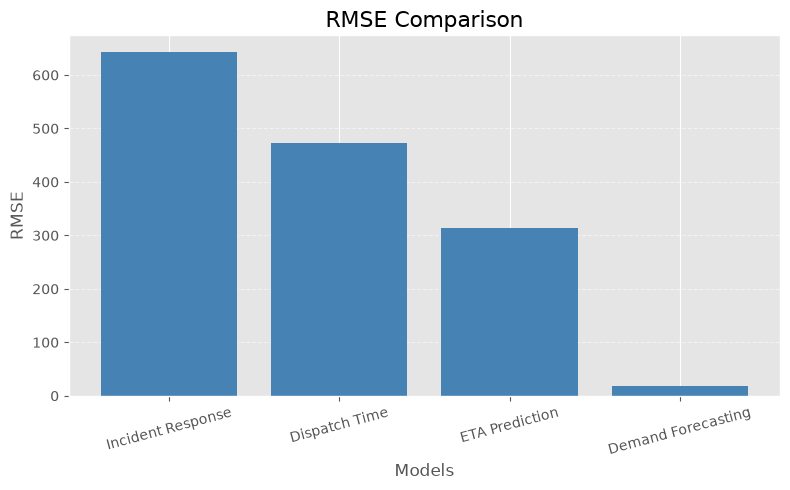

In [44]:
plt.figure(figsize=(8,5))
plt.bar(reg["Model"], reg["RMSE"], color="steelblue")
plt.title("RMSE Comparison", fontsize=16)
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [45]:
ranking = results.sort_values(
    by="R2",
    ascending=False
)

ranking

,Model,MAE,RMSE,R2,Accuracy,Precision,Recall,F1 Score
2,ETA Prediction,40.124260,313.557648,0.927650,NaN,NaN,NaN,NaN
4,Demand Forecasting,13.731746,17.805371,0.896164,NaN,NaN,NaN,NaN
1,Dispatch Time,108.120209,473.528543,0.674482,NaN,NaN,NaN,NaN
0,Incident Response,307.195549,642.109073,0.648412,NaN,NaN,NaN,NaN
3,Delay Classification,NaN,NaN,NaN,0.726019,0.792296,0.763066,0.777407


## Strengths

✔ High ETA Prediction Accuracy

✔ Strong Demand Forecasting

✔ Good Generalization

✔ Low Prediction Error

✔ Multiple ML Algorithms Compared

## Limitations

• Delay Classification Accuracy can be further improved.

• Response Time prediction can benefit from additional spatial and traffic features.

• External real-time factors (weather, traffic congestion) are not included.